In [1]:
import pandas as pd
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import os
import tensorflow as tf

# File paths

In [2]:
filedr = r'C:\Car color Detection project'
train_path = os.path.join(filedr, 'train')
test_path = os.path.join(filedr, 'test')
val_path = os.path.join(filedr, 'val')

# Load images

In [3]:
def load_images_from_folder(folder_path):
    images = []
    labels = []
    color_classes = os.listdir(folder_path)
    for color_class in color_classes:
        color_path = os.path.join(folder_path, color_class)
        for filename in os.listdir(color_path):
            img = Image.open(os.path.join(color_path, filename)).convert('RGB')
            img = img.resize((128, 128))
            images.append(np.array(img))
            labels.append(color_class)
    return images, labels


In [4]:
train_images, train_labels = load_images_from_folder(train_path)
test_images, test_labels = load_images_from_folder(test_path)
val_images, val_labels = load_images_from_folder(val_path)

In [5]:
images = train_images + test_images + val_images
colors = train_labels + test_labels + val_labels




# Show color distribution

C:\Users\anshu yadav\AppData\Local\Temp\ipykernel_1868\3489040783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(colors_count.keys()), y=list(colors_count.values()),


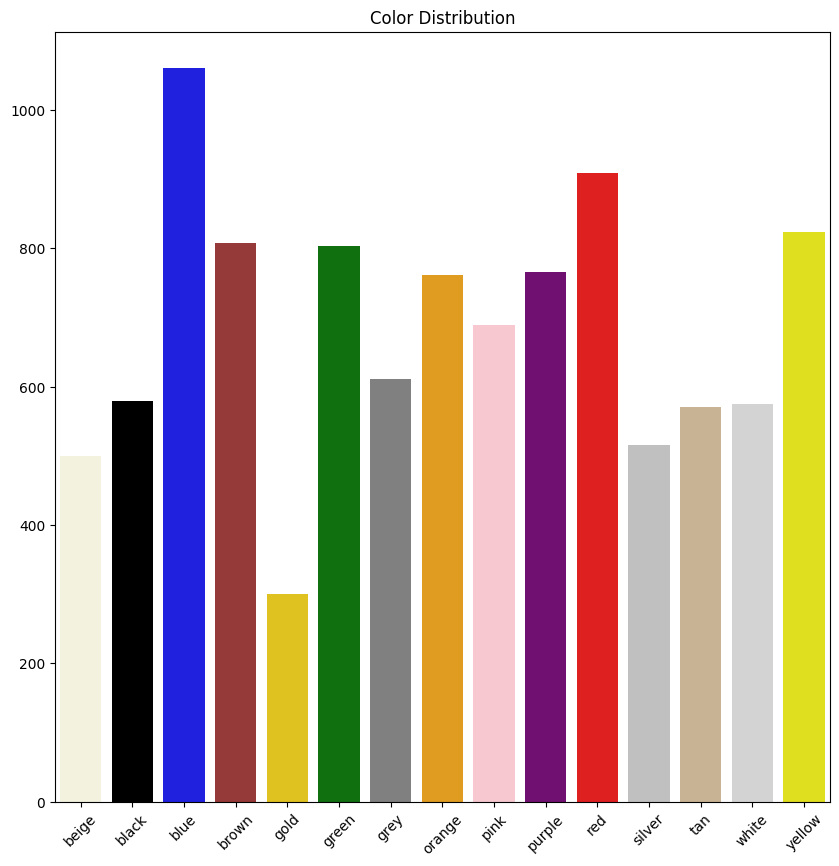

In [6]:
colors_count = dict(Counter(colors))
plt.figure(figsize=(10,10))
sns.barplot(x=list(colors_count.keys()), y=list(colors_count.values()),
            palette={key: key if key.lower() != 'white' else 'lightgrey' for key in colors_count})
plt.title("Color Distribution")
plt.xticks(rotation=45)
plt.show()


# Data augmentation

In [7]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)
images_augmented = [datagen.random_transform(img) for img in images]

# Label encoding

In [8]:
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(colors)


# Check encoded classes

In [9]:
labelled = sorted(list(set(zip(colors, numerical_labels))))
print("Encoded labels:", labelled)

Encoded labels: [('beige', 0), ('black', 1), ('blue', 2), ('brown', 3), ('gold', 4), ('green', 5), ('grey', 6), ('orange', 7), ('pink', 8), ('purple', 9), ('red', 10), ('silver', 11), ('tan', 12), ('white', 13), ('yellow', 14)]


In [10]:
# Normalize
images_f = np.array(images_augmented) / 255.0
labels_f = np.array(numerical_labels)

# Train-val-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(images_f, labels_f, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.75, random_state=3)



# Class weights

In [12]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), class_weights))


# Defining model

In [13]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0001), input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels_f)), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


c:\Users\anshu yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,700,687 (6.49 MB)

 Trainable params: 1,700,687 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
fle_s='Car_Color_Detection.h5'
checkpoint=ModelCheckpoint(fle_s,monitor='val_loss',verbose=1,save_best_only=True,save_weights_only=False, mode="auto",save_freq='epoch')
early_stop=tf.keras.callbacks.EarlyStopping(patience=50,monitor='val_loss',restore_best_weights='True')
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, verbose=1, factor=0.5)
callback_list=[checkpoint,early_stop, lr_scheduler]


In [17]:
history = model.fit(X_train, y_train, epochs=150, batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[checkpoint, early_stop, lr_scheduler],
                    class_weight=class_weight)

Epoch 1/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.1222 - loss: 2.7033
Epoch 1: val_loss improved from inf to 1.98695, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - accuracy: 0.1225 - loss: 2.7027 - val_accuracy: 0.4091 - val_loss: 1.9870 - learning_rate: 5.0000e-05
Epoch 2/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.3671 - loss: 2.0771
Epoch 2: val_loss improved from 1.98695 to 1.50398, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 56s 250ms/step - accuracy: 0.3672 - loss: 2.0767 - val_accuracy: 0.5636 - val_loss: 1.5040 - learning_rate: 5.0000e-05
Epoch 3/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.4542 - loss: 1.8037
Epoch 3: val_loss improved from 1.50398 to 1.31424, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 53s 235ms/step - accuracy: 0.4543 - loss: 1.8036 - val_accuracy: 0.6169 - val_loss: 1.3142 - learning_rate: 5.0000e-05
Epoch 4/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5093 - loss: 1.6674
Epoch 4: val_loss improved from 1.31424 to 1.21526, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - accuracy: 0.5094 - loss: 1.6673 - val_accuracy: 0.6182 - val_loss: 1.2153 - learning_rate: 5.0000e-05
Epoch 5/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.5335 - loss: 1.5924
Epoch 5: val_loss improved from 1.21526 to 1.21187, saving model to Car_Color_Detection.h5


...

225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.7719 - loss: 0.8068 - val_accuracy: 0.7740 - val_loss: 0.6823 - learning_rate: 2.5000e-05
Epoch 36/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7571 - loss: 0.8201
Epoch 36: val_loss improved from 0.68232 to 0.67146, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 38s 170ms/step - accuracy: 0.7571 - loss: 0.8201 - val_accuracy: 0.7818 - val_loss: 0.6715 - learning_rate: 2.5000e-05
Epoch 37/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7697 - loss: 0.8081
Epoch 37: val_loss did not improve from 0.67146
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step - accuracy: 0.7697 - loss: 0.8081 - val_accuracy: 0.7779 - val_loss: 0.6884 - learning_rate: 2.5000e-05
Epoch 38/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7694 - loss: 0.7971
Epoch 38: val_loss did not improve from 0.67146
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 175ms/step - accuracy: 0.7694 - loss: 0.7972 - val_accuracy: 0.7753 - val_loss: 0.6945 - learning_rate: 2.5000e-05
Epoch 39/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7712 - loss: 0.7965
Epoch 39: val_loss did not improve from 0.67146

Epoch 39: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.7712 -

225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step - accuracy: 0.7801 - loss: 0.7579 - val_accuracy: 0.7766 - val_loss: 0.6571 - learning_rate: 6.2500e-06
Epoch 44/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7859 - loss: 0.7327
Epoch 44: val_loss did not improve from 0.65705
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step - accuracy: 0.7859 - loss: 0.7327 - val_accuracy: 0.7779 - val_loss: 0.6641 - learning_rate: 6.2500e-06
Epoch 45/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7882 - loss: 0.7439
Epoch 45: val_loss did not improve from 0.65705
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.7882 - loss: 0.7439 - val_accuracy: 0.7779 - val_loss: 0.6584 - learning_rate: 6.2500e-06
Epoch 46/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7938 - loss: 0.7213
Epoch 46: val_loss did not improve from 0.65705

Epoch 46: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.7938 - 

225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.7945 - loss: 0.7384 - val_accuracy: 0.7870 - val_loss: 0.6569 - learning_rate: 3.1250e-06
Epoch 48/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7849 - loss: 0.7540
Epoch 48: val_loss did not improve from 0.65693
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.7849 - loss: 0.7539 - val_accuracy: 0.7805 - val_loss: 0.6587 - learning_rate: 3.1250e-06
Epoch 49/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7989 - loss: 0.7181
Epoch 49: val_loss improved from 0.65693 to 0.65594, saving model to Car_Color_Detection.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 173ms/step - accuracy: 0.7989 - loss: 0.7181 - val_accuracy: 0.7805 - val_loss: 0.6559 - learning_rate: 3.1250e-06
Epoch 50/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7878 - loss: 0.7264
Epoch 50: val_loss did not improve from 0.65594
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.7878 - loss: 0.7264 - val_accuracy: 0.7727 - val_loss: 0.6591 - learning_rate: 3.1250e-06
Epoch 51/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7857 - loss: 0.7125
Epoch 51: val_loss did not improve from 0.65594
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - accuracy: 0.7857 - loss: 0.7126 - val_accuracy: 0.7740 - val_loss: 0.6575 - learning_rate: 3.1250e-06
Epoch 52/150
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7859 - loss: 0.7465
Epoch 52: val_loss did not improve from 0.65594

Epoch 52: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-06.
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.7859 - 

# Plotting loss

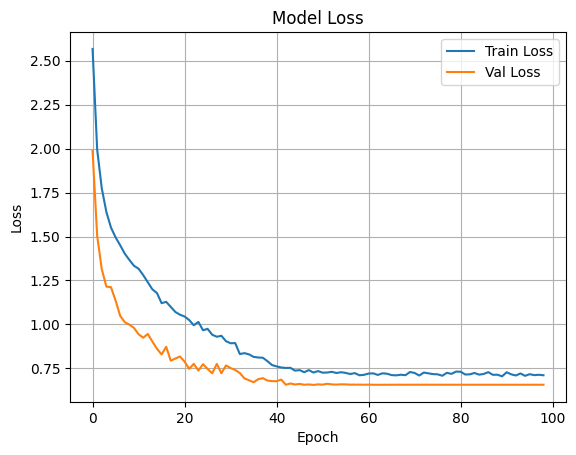

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plotting Accurcay

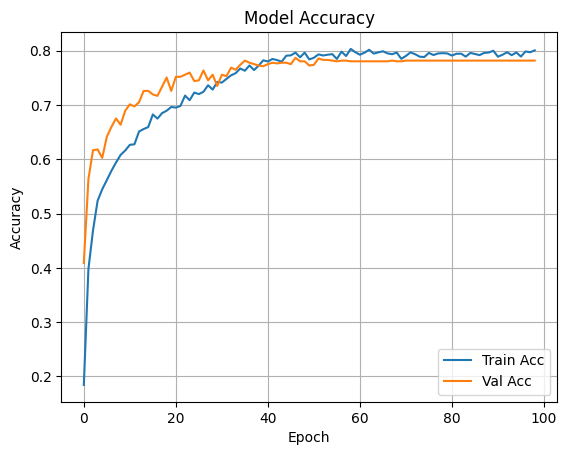

In [19]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


# Model evaluation

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7696 - loss: 0.7092
Test Loss: 0.7363, Test Accuracy: 0.7539


In [21]:
pred = model.predict(X_test)
pred_labels = np.argmax(pred, axis=1)

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


In [22]:
print("Classification Report:")
print(classification_report(y_test, pred_labels, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

       beige       0.37      0.36      0.36       128
       black       0.66      0.73      0.70       132
        blue       0.90      0.91      0.90       248
       brown       0.69      0.67      0.68       189
        gold       0.50      0.45      0.47        69
       green       0.92      0.91      0.91       159
        grey       0.59      0.56      0.57       151
      orange       0.85      0.84      0.85       164
        pink       0.88      0.92      0.90       171
      purple       0.92      0.90      0.91       180
         red       0.90      0.86      0.88       214
      silver       0.53      0.47      0.50       107
         tan       0.38      0.45      0.42       121
       white       0.78      0.83      0.80       115
      yellow       0.91      0.90      0.90       164

    accuracy                           0.75      2312
   macro avg       0.72      0.72      0.72      2312
wei

# Confusion matrix 

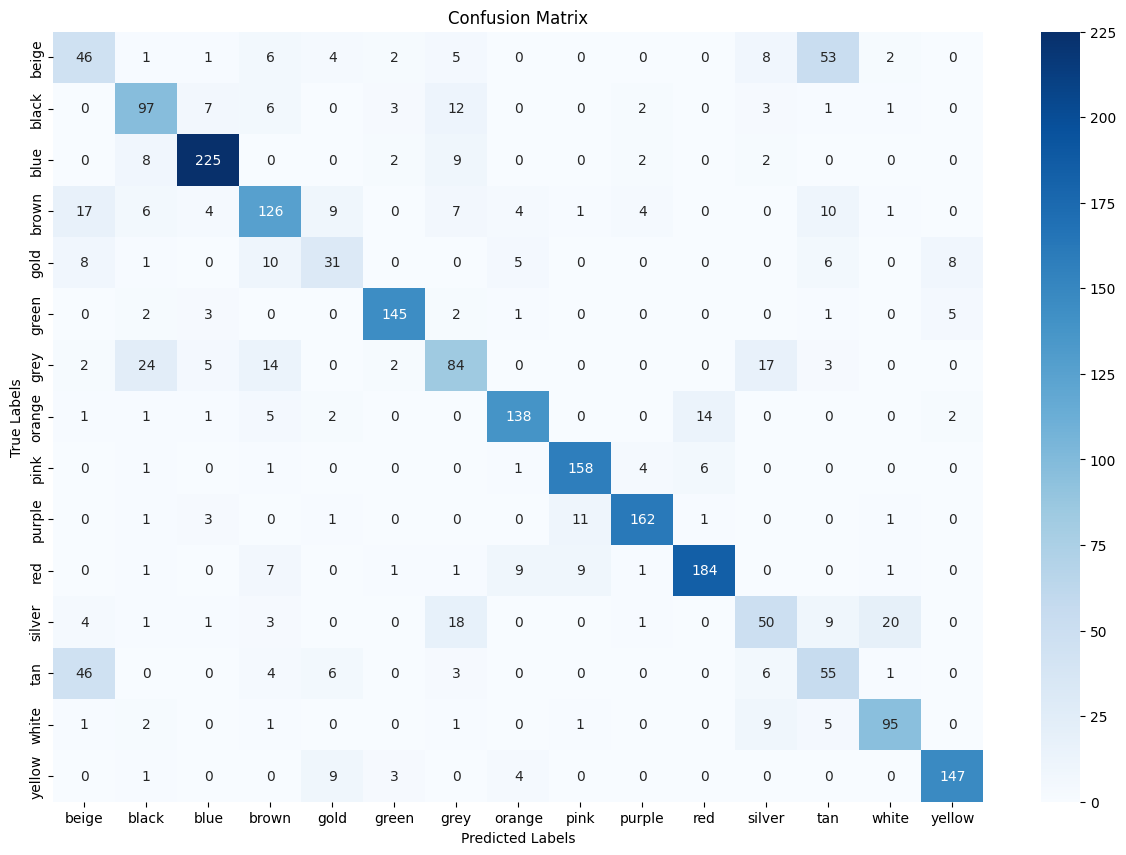

In [23]:
cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Model Testing

In [24]:

def predict_custom_image(image_path):
    # Load and preprocess the image
    img = Image.open(image_path).convert('RGB')
    img = img.resize((128, 128))
    img_array = np.array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict using the model
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]

    # Show the image with prediction
    plt.imshow(img)
    plt.title(f"Predicted Color: {predicted_label}")
    plt.axis('off')
    plt.show()

    return predicted_label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


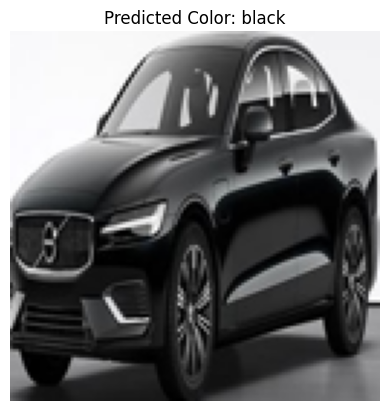

'black'

In [25]:
image_path = r'C:\Car color Detection project\test\black\1e96fbafd9.jpg'
predict_custom_image(image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


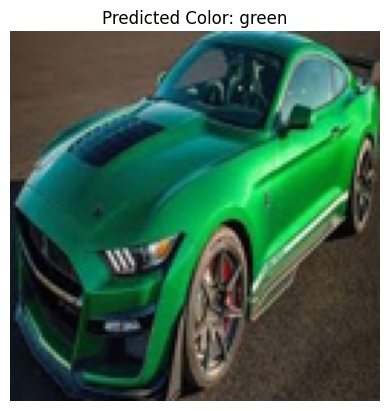

'green'

In [26]:
image_path = r'C:\Car color Detection project\test\green\1b203c6b70.jpg'
predict_custom_image(image_path)